#  Restaurant Waste Intelligence & Demand-Aware Preparation

## Data Science Hackathon — DS_Day01_18

### Problem Statement
A large restaurant chain is experiencing excessive food wastage.
The objective is to identify the major drivers of food waste,
understand product and outlet-level patterns, evaluate the impact
of promotions and operational conditions, and determine whether
demand forecasting can improve food preparation decisions.

### Key Objectives

1. Measure and analyze food waste.
2. Identify products with consistently high waste.
3. Compare waste across restaurant outlets.
4. Analyze the effect of promotions.
5. Compare weekday and weekend behavior.
6. Analyze the influence of weather, holidays and special events.
7. Build and evaluate a Random Forest model.
8. Develop demand-aware preparation recommendations.
9. Propose a practical waste-reduction strategy.

### Dataset Note

No dataset is provided therefore a synthetic dataset is generated for the analysis.

In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta

# Reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
# ============================================
# DEFINE RESTAURANT UNIVERSE
# ============================================

# Number of outlets
outlets = [f"O{i:03d}" for i in range(1, 13)]

# Products
products = {
    "P001": "Burger",
    "P002": "Pizza",
    "P003": "Chicken Wings",
    "P004": "French Fries",
    "P005": "Pasta",
    "P006": "Sandwich",
    "P007": "Wrap",
    "P008": "Biryani",
    "P009": "Fried Rice",
    "P010": "Noodles",
    "P011": "Grilled Chicken",
    "P012": "Chicken Rice",
    "P013": "Veg Rice",
    "P014": "Paneer Wrap",
    "P015": "Paneer Pizza",
    "P016": "Veg Burger",
    "P017": "Veg Sandwich",
    "P018": "Tacos",
    "P019": "Nachos",
    "P020": "Garlic Bread",
    "P021": "Soup",
    "P022": "Salad",
    "P023": "Momos",
    "P024": "Spring Rolls",
    "P025": "Hot Dog",
    "P026": "Pancakes",
    "P027": "Brownie",
    "P028": "Ice Cream",
    "P029": "Milkshake",
    "P030": "Fresh Juice"
}

print("Number of outlets:", len(outlets))
print("Number of products:", len(products))

Number of outlets: 12
Number of products: 30


In [15]:
# ============================================
#  DEFINE DATE RANGE
# ============================================

start_date = "2024-01-01"
end_date = "2025-12-31"

dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="D"
)

print("Start date:", dates.min().date())
print("End date:", dates.max().date())
print("Number of days:", len(dates))

Start date: 2024-01-01
End date: 2025-12-31
Number of days: 731


In [16]:
# ============================================
# CREATE BASE DATASET
# ============================================

product_df = pd.DataFrame(
    list(products.items()),
    columns=["Product_ID", "Product_Name"]
)

date_df = pd.DataFrame({"Date": dates})

outlet_df = pd.DataFrame({"Outlet_ID": outlets})

# Cartesian product:
# Date × Outlet × Product

df = (
    date_df
    .merge(outlet_df, how="cross")
    .merge(product_df, how="cross")
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (263160, 4)


,Date,Outlet_ID,Product_ID,Product_Name
0,2024-01-01,O001,P001,Burger
1,2024-01-01,O001,P002,Pizza
2,2024-01-01,O001,P003,Chicken Wings
3,2024-01-01,O001,P004,French Fries
4,2024-01-01,O001,P005,Pasta


In [17]:
# ============================================
#   CALENDAR FEATURES
# ============================================

df["Day_of_Week"] = df["Date"].dt.day_name()
df["Day_Number"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day_of_Month"] = df["Date"].dt.day

# Weekend flag
df["Weekend"] = (df["Day_Number"] >= 5).astype(int)

print(df[[
    "Date",
    "Day_of_Week",
    "Month",
    "Weekend"
]].head(10))

        Date Day_of_Week  Month  Weekend
0 2024-01-01      Monday      1        0
1 2024-01-01      Monday      1        0
2 2024-01-01      Monday      1        0
3 2024-01-01      Monday      1        0
4 2024-01-01      Monday      1        0
5 2024-01-01      Monday      1        0
6 2024-01-01      Monday      1        0
7 2024-01-01      Monday      1        0
8 2024-01-01      Monday      1        0
9 2024-01-01      Monday      1        0


In [18]:
# ============================================
# MAKE WEATHER DATE-LEVEL
# ============================================

# Remove the old product-level weather column
if "Weather" in df.columns:
    df = df.drop(columns=["Weather"])

# Generate one weather condition for each date
daily_weather = pd.DataFrame({
    "Date": dates,
    "Weather": np.random.choice(
        ["Sunny", "Cloudy", "Rainy", "Stormy"],
        size=len(dates),
        p=[0.45, 0.30, 0.20, 0.05]
    )
})

# Add date-level weather to the main dataset
df = df.merge(
    daily_weather,
    on="Date",
    how="left"
)

# Check that each date has only one weather condition
weather_check = df.groupby("Date")["Weather"].nunique()

print("Weather consistency check:")
print(weather_check.value_counts())

Weather consistency check:
Weather
1    731
Name: count, dtype: int64


In [19]:
# ============================================
#  HOLIDAY
# ============================================

holiday_dates = pd.to_datetime([
    "2024-01-01",
    "2024-01-26",
    "2024-05-01",
    "2024-08-15",
    "2024-10-02",
    "2024-12-25",
    "2025-01-01",
    "2025-01-26",
    "2025-05-01",
    "2025-08-15",
    "2025-10-02",
    "2025-12-25"
])

df["Holiday"] = df["Date"].isin(holiday_dates).astype(int)

print("Holiday records:", df["Holiday"].sum())

Holiday records: 4320


In [20]:
# ============================================
#  PROMOTIONS
# ============================================

promotion_probability = np.where(
    df["Weekend"] == 1,
    0.30,
    0.18
)

df["Promotion"] = (
    np.random.random(len(df)) < promotion_probability
).astype(int)

print(df["Promotion"].value_counts(normalize=True))

Promotion
0    0.785948
1    0.214052
Name: proportion, dtype: float64


In [21]:
# ============================================
# SPECIAL EVENTS
# ============================================

event_probability = np.where(
    df["Weekend"] == 1,
    0.12,
    0.05
)

df["Special_Event"] = (
    np.random.random(len(df)) < event_probability
).astype(int)

print(df["Special_Event"].value_counts(normalize=True))

Special_Event
0    0.930544
1    0.069456
Name: proportion, dtype: float64


In [22]:
# ============================================
#  DATASET CHECK
# ============================================

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSample:")
display(df.head())

Shape: (263160, 14)

Columns:
['Date', 'Outlet_ID', 'Product_ID', 'Product_Name', 'Day_of_Week', 'Day_Number', 'Month', 'Month_Name', 'Day_of_Month', 'Weekend', 'Weather', 'Holiday', 'Promotion', 'Special_Event']

Missing values:
Date             0
Outlet_ID        0
Product_ID       0
Product_Name     0
Day_of_Week      0
Day_Number       0
Month            0
Month_Name       0
Day_of_Month     0
Weekend          0
Weather          0
Holiday          0
Promotion        0
Special_Event    0
dtype: int64

Sample:


,Date,Outlet_ID,Product_ID,Product_Name,Day_of_Week,Day_Number,Month,Month_Name,Day_of_Month,Weekend,Weather,Holiday,Promotion,Special_Event
0,2024-01-01,O001,P001,Burger,Monday,0,1,January,1,0,Sunny,1,0,0
1,2024-01-01,O001,P002,Pizza,Monday,0,1,January,1,0,Sunny,1,0,0
2,2024-01-01,O001,P003,Chicken Wings,Monday,0,1,January,1,0,Sunny,1,0,0
3,2024-01-01,O001,P004,French Fries,Monday,0,1,January,1,0,Sunny,1,0,0
4,2024-01-01,O001,P005,Pasta,Monday,0,1,January,1,0,Sunny,1,0,0


In [23]:
# ============================================
# PRODUCT DEMAND PROFILES
# ============================================

product_demand = {
    "P001": 85,   # Burger
    "P002": 70,   # Pizza
    "P003": 55,   # Chicken Wings
    "P004": 100,  # French Fries
    "P005": 60,   # Pasta
    "P006": 50,   # Sandwich
    "P007": 55,   # Wrap
    "P008": 75,   # Biryani
    "P009": 65,   # Fried Rice
    "P010": 60,   # Noodles
    "P011": 45,   # Grilled Chicken
    "P012": 65,   # Chicken Rice
    "P013": 45,   # Veg Rice
    "P014": 40,   # Paneer Wrap
    "P015": 35,   # Paneer Pizza
    "P016": 55,   # Veg Burger
    "P017": 40,   # Veg Sandwich
    "P018": 35,   # Tacos
    "P019": 45,   # Nachos
    "P020": 50,   # Garlic Bread
    "P021": 30,   # Soup
    "P022": 25,   # Salad
    "P023": 45,   # Momos
    "P024": 35,   # Spring Rolls
    "P025": 30,   # Hot Dog
    "P026": 25,   # Pancakes
    "P027": 30,   # Brownie
    "P028": 35,   # Ice Cream
    "P029": 40,   # Milkshake
    "P030": 45    # Fresh Juice
}

# Assign the base demand to each product
df["Base_Demand"] = df["Product_ID"].map(product_demand)

# Check the result
print(
    df[
        ["Product_ID", "Product_Name", "Base_Demand"]
    ].drop_duplicates().head(10)
)

  Product_ID   Product_Name  Base_Demand
0       P001         Burger           85
1       P002          Pizza           70
2       P003  Chicken Wings           55
3       P004   French Fries          100
4       P005          Pasta           60
5       P006       Sandwich           50
6       P007           Wrap           55
7       P008        Biryani           75
8       P009     Fried Rice           65
9       P010        Noodles           60


In [24]:
# ============================================
# OUTLET DEMAND PROFILES
# ============================================

outlet_factors = {
    "O001": 1.20,
    "O002": 0.95,
    "O003": 1.10,
    "O004": 0.85,
    "O005": 1.25,
    "O006": 1.00,
    "O007": 0.80,
    "O008": 1.15,
    "O009": 0.90,
    "O010": 1.30,
    "O011": 1.05,
    "O012": 0.88
}

df["Outlet_Factor"] = df["Outlet_ID"].map(outlet_factors)

print(
    df[["Outlet_ID", "Outlet_Factor"]]
    .drop_duplicates()
    .sort_values("Outlet_ID")
)

    Outlet_ID  Outlet_Factor
0        O001           1.20
30       O002           0.95
60       O003           1.10
90       O004           0.85
120      O005           1.25
150      O006           1.00
180      O007           0.80
210      O008           1.15
240      O009           0.90
270      O010           1.30
300      O011           1.05
330      O012           0.88


In [25]:
# ============================================
# WEEKDAY / WEEKEND DEMAND EFFECT
# ============================================

df["Day_Factor"] = np.where(
    df["Weekend"] == 1,
    1.20,   # Weekend demand is 20% higher
    1.00    # Normal weekday
)

# Friday gets a smaller demand boost
df.loc[
    df["Day_of_Week"] == "Friday",
    "Day_Factor"
] = 1.10

print(
    df[
        ["Day_of_Week", "Weekend", "Day_Factor"]
    ].drop_duplicates().sort_values("Day_of_Week")
)

     Day_of_Week  Weekend  Day_Factor
1440      Friday        0         1.1
0         Monday        0         1.0
1800    Saturday        1         1.2
2160      Sunday        1         1.2
1080    Thursday        0         1.0
360      Tuesday        0         1.0
720    Wednesday        0         1.0


In [26]:
# ============================================
# PROMOTION EFFECT
# ============================================

df["Promotion_Factor"] = np.where(
    df["Promotion"] == 1,
    1.25,   # Promotion increases demand by 25%
    1.00
)

print(
    df[
        ["Promotion", "Promotion_Factor"]
    ].drop_duplicates().sort_values("Promotion")
)

    Promotion  Promotion_Factor
0           0              1.00
19          1              1.25


In [27]:
# ============================================
# WEATHER EFFECT
# ============================================

df["Weather_Factor"] = 1.00

# Rain increases demand for some hot-food products
rainy = df["Weather"] == "Rainy"

df.loc[
    rainy & df["Product_Name"].isin(
        ["Soup", "Pasta", "Noodles"]
    ),
    "Weather_Factor"
] = 1.15

# Rain decreases demand for cold drinks/desserts
df.loc[
    rainy & df["Product_Name"].isin(
        ["Ice Cream", "Milkshake", "Fresh Juice"]
    ),
    "Weather_Factor"
] = 0.75

# Stormy weather generally reduces restaurant traffic
stormy = df["Weather"] == "Stormy"

df.loc[
    stormy,
    "Weather_Factor"
] *= 0.80

print(
    df[
        ["Weather", "Product_Name", "Weather_Factor"]
    ].drop_duplicates().head(20)
)

   Weather     Product_Name  Weather_Factor
0    Sunny           Burger             1.0
1    Sunny            Pizza             1.0
2    Sunny    Chicken Wings             1.0
3    Sunny     French Fries             1.0
4    Sunny            Pasta             1.0
5    Sunny         Sandwich             1.0
6    Sunny             Wrap             1.0
7    Sunny          Biryani             1.0
8    Sunny       Fried Rice             1.0
9    Sunny          Noodles             1.0
10   Sunny  Grilled Chicken             1.0
11   Sunny     Chicken Rice             1.0
12   Sunny         Veg Rice             1.0
13   Sunny      Paneer Wrap             1.0
14   Sunny     Paneer Pizza             1.0
15   Sunny       Veg Burger             1.0
16   Sunny     Veg Sandwich             1.0
17   Sunny            Tacos             1.0
18   Sunny           Nachos             1.0
19   Sunny     Garlic Bread             1.0


In [28]:
# ============================================
# HOLIDAY EFFECT
# ============================================

df["Holiday_Factor"] = np.where(
    df["Holiday"] == 1,
    1.30,   # Holiday demand is 30% higher
    1.00
)

print(
    df[
        ["Holiday", "Holiday_Factor"]
    ].drop_duplicates().sort_values("Holiday")
)

     Holiday  Holiday_Factor
360        0             1.0
0          1             1.3


In [29]:
# ============================================
# SPECIAL EVENT EFFECT
# ============================================

df["Event_Factor"] = np.where(
    df["Special_Event"] == 1,
    1.40,   # Special event demand is 40% higher
    1.00
)

print(
    df[
        ["Special_Event", "Event_Factor"]
    ].drop_duplicates().sort_values("Special_Event")
)

    Special_Event  Event_Factor
0               0           1.0
10              1           1.4


In [30]:
# ============================================
# EXPECTED DEMAND
# ============================================

df["Expected_Demand"] = (
    df["Base_Demand"]
    * df["Outlet_Factor"]
    * df["Day_Factor"]
    * df["Promotion_Factor"]
    * df["Weather_Factor"]
    * df["Holiday_Factor"]
    * df["Event_Factor"]
)

print(
    df[
        [
            "Product_Name",
            "Base_Demand",
            "Outlet_Factor",
            "Day_Factor",
            "Promotion_Factor",
            "Weather_Factor",
            "Holiday_Factor",
            "Event_Factor",
            "Expected_Demand"
        ]
    ].head(10)
)

    Product_Name  Base_Demand  Outlet_Factor  Day_Factor  Promotion_Factor  \
0         Burger           85            1.2         1.0               1.0   
1          Pizza           70            1.2         1.0               1.0   
2  Chicken Wings           55            1.2         1.0               1.0   
3   French Fries          100            1.2         1.0               1.0   
4          Pasta           60            1.2         1.0               1.0   
5       Sandwich           50            1.2         1.0               1.0   
6           Wrap           55            1.2         1.0               1.0   
7        Biryani           75            1.2         1.0               1.0   
8     Fried Rice           65            1.2         1.0               1.0   
9        Noodles           60            1.2         1.0               1.0   

   Weather_Factor  Holiday_Factor  Event_Factor  Expected_Demand  
0             1.0             1.3           1.0            132.6  
1      

In [31]:
# ============================================
# ACTUAL DEMAND
# ============================================

# Add realistic day-to-day variation
noise = np.random.normal(
    loc=0,
    scale=8,
    size=len(df)
)

df["True_Demand"] = (
    df["Expected_Demand"] + noise
).clip(lower=0)

# Demand must be a whole number
df["True_Demand"] = df["True_Demand"].round().astype(int)

print(
    df["True_Demand"].describe()
)

count    263160.000000
mean         58.515986
std          27.242708
min           0.000000
25%          39.000000
50%          54.000000
75%          72.000000
max         277.000000
Name: True_Demand, dtype: float64


In [32]:
# ============================================
# QUANTITY PREPARED
# ============================================

# Restaurants prepare food based on expected demand,
# but they do not know the exact actual demand.

# Base preparation buffer
preparation_buffer = 1.15

df["Quantity_Prepared"] = (
    df["Expected_Demand"] * preparation_buffer
)

# Add some operational variation
prep_noise = np.random.normal(
    loc=0,
    scale=5,
    size=len(df)
)

df["Quantity_Prepared"] = (
    df["Quantity_Prepared"] + prep_noise
).clip(lower=0)

# Round to whole units
df["Quantity_Prepared"] = (
    df["Quantity_Prepared"]
    .round()
    .astype(int)
)

print(
    df["Quantity_Prepared"].describe()
)

count    263160.000000
mean         67.310059
std          30.362530
min           3.000000
25%          46.000000
50%          61.000000
75%          82.000000
max         320.000000
Name: Quantity_Prepared, dtype: float64


In [33]:
# ============================================
# QUANTITY SOLD
# ============================================

df["Quantity_Sold"] = np.minimum(
    df["True_Demand"],
    df["Quantity_Prepared"]
)

# Check the result
print(
    df[
        [
            "True_Demand",
            "Quantity_Prepared",
            "Quantity_Sold"
        ]
    ].head(10)
)

   True_Demand  Quantity_Prepared  Quantity_Sold
0          134                147            134
1          117                129            117
2           97                 92             92
3          158                182            158
4           92                109             92
5           65                 88             65
6           88                104             88
7          121                126            121
8           96                116             96
9          104                104            104


In [34]:
# ============================================
# QUANTITY DISCARDED
# ============================================

df["Quantity_Discarded"] = (
    df["Quantity_Prepared"] - df["Quantity_Sold"]
)

# Safety check
df["Quantity_Discarded"] = (
    df["Quantity_Discarded"].clip(lower=0)
)

print(
    df[
        [
            "Quantity_Prepared",
            "Quantity_Sold",
            "Quantity_Discarded"
        ]
    ].head(10)
)

   Quantity_Prepared  Quantity_Sold  Quantity_Discarded
0                147            134                  13
1                129            117                  12
2                 92             92                   0
3                182            158                  24
4                109             92                  17
5                 88             65                  23
6                104             88                  16
7                126            121                   5
8                116             96                  20
9                104            104                   0


In [35]:
# ============================================
# DATA CONSISTENCY CHECK
# ============================================

print(
    "Sold <= Prepared:",
    (df["Quantity_Sold"] <= df["Quantity_Prepared"]).all()
)

print(
    "Discarded >= 0:",
    (df["Quantity_Discarded"] >= 0).all()
)

print(
    "Prepared = Sold + Discarded:",
    (
        df["Quantity_Prepared"]
        == df["Quantity_Sold"] + df["Quantity_Discarded"]
    ).all()
)

Sold <= Prepared: True
Discarded >= 0: True
Prepared = Sold + Discarded: True


In [36]:
# ============================================
# DATASET OVERVIEW
# ============================================

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (263160, 26)

Columns:
['Date', 'Outlet_ID', 'Product_ID', 'Product_Name', 'Day_of_Week', 'Day_Number', 'Month', 'Month_Name', 'Day_of_Month', 'Weekend', 'Weather', 'Holiday', 'Promotion', 'Special_Event', 'Base_Demand', 'Outlet_Factor', 'Day_Factor', 'Promotion_Factor', 'Weather_Factor', 'Holiday_Factor', 'Event_Factor', 'Expected_Demand', 'True_Demand', 'Quantity_Prepared', 'Quantity_Sold', 'Quantity_Discarded']

Missing Values:
0

Data Types:
Date                  datetime64[ns]
Outlet_ID                     object
Product_ID                    object
Product_Name                  object
Day_of_Week                   object
Day_Number                     int32
Month                          int32
Month_Name                    object
Day_of_Month                   int32
Weekend                        int64
Weather                       object
Holiday                        int64
Promotion                      int64
Special_Event                  int64
Base_Demand      

In [37]:
# ============================================
# LOST DEMAND
# ============================================

df["Lost_Demand"] = (
    df["True_Demand"] - df["Quantity_Sold"]
).clip(lower=0)

print(
    df[
        [
            "True_Demand",
            "Quantity_Prepared",
            "Quantity_Sold",
            "Quantity_Discarded",
            "Lost_Demand"
        ]
    ].head(10)
)

   True_Demand  Quantity_Prepared  Quantity_Sold  Quantity_Discarded  \
0          134                147            134                  13   
1          117                129            117                  12   
2           97                 92             92                   0   
3          158                182            158                  24   
4           92                109             92                  17   
5           65                 88             65                  23   
6           88                104             88                  16   
7          121                126            121                   5   
8           96                116             96                  20   
9          104                104            104                   0   

   Lost_Demand  
0            0  
1            0  
2            5  
3            0  
4            0  
5            0  
6            0  
7            0  
8            0  
9            0  


In [38]:
# ============================================
# OVERALL WASTE KPIs
# ============================================

total_prepared = df["Quantity_Prepared"].sum()
total_sold = df["Quantity_Sold"].sum()
total_discarded = df["Quantity_Discarded"].sum()

waste_rate = (
    total_discarded / total_prepared
) * 100

sell_through_rate = (
    total_sold / total_prepared
) * 100

print("Total Quantity Prepared :", total_prepared)
print("Total Quantity Sold     :", total_sold)
print("Total Quantity Discarded:", total_discarded)

print("\nWaste Rate              :", round(waste_rate, 2), "%")
print("Sell-through Rate       :", round(sell_through_rate, 2), "%")

Total Quantity Prepared : 17713315
Total Quantity Sold     : 15118503
Total Quantity Discarded: 2594812

Waste Rate              : 14.65 %
Sell-through Rate       : 85.35 %


In [39]:
# ============================================
# WASTE BY PRODUCT
# ============================================

product_waste = (
    df.groupby(["Product_ID", "Product_Name"])
      .agg(
          Total_Prepared=("Quantity_Prepared", "sum"),
          Total_Sold=("Quantity_Sold", "sum"),
          Total_Discarded=("Quantity_Discarded", "sum")
      )
      .reset_index()
)

product_waste["Waste_Rate"] = (
    product_waste["Total_Discarded"]
    / product_waste["Total_Prepared"]
) * 100

product_waste = product_waste.sort_values(
    "Waste_Rate",
    ascending=False
)

product_waste.head(10)

,Product_ID,Product_Name,Total_Prepared,Total_Sold,Total_Discarded,Waste_Rate
21,P022,Salad,301960,245063,56897,18.842562
25,P026,Pancakes,300936,244901,56035,18.620238
24,P025,Hot Dog,363086,299724,63362,17.450962
26,P027,Brownie,361302,298866,62436,17.280834
20,P021,Soup,374458,309811,64647,17.264152
27,P028,Ice Cream,400709,334421,66288,16.542678
23,P024,Spring Rolls,421744,353035,68709,16.291637
17,P018,Tacos,422191,354124,68067,16.122324
14,P015,Paneer Pizza,423036,355262,67774,16.020859
28,P029,Milkshake,458703,386707,71996,15.695559


In [40]:
# ============================================
# TOP PRODUCTS BY TOTAL DISCARDED QUANTITY
# ============================================

top_discarded = product_waste.sort_values(
    "Total_Discarded",
    ascending=False
)

top_discarded[
    [
        "Product_ID",
        "Product_Name",
        "Total_Prepared",
        "Total_Sold",
        "Total_Discarded",
        "Waste_Rate"
    ]
].head(10)

,Product_ID,Product_Name,Total_Prepared,Total_Sold,Total_Discarded,Waste_Rate
3,P004,French Fries,1208742,1048265,160477,13.276365
0,P001,Burger,1023604,887862,135742,13.261183
7,P008,Biryani,905838,784665,121173,13.376895
1,P002,Pizza,843907,729800,114107,13.521277
8,P009,Fried Rice,783814,675632,108182,13.801999
11,P012,Chicken Rice,782236,674912,107324,13.720156
9,P010,Noodles,744479,641192,103287,13.873729
4,P005,Pasta,744963,641835,103128,13.843372
2,P003,Chicken Wings,664498,571364,93134,14.015693
6,P007,Wrap,663141,570261,92880,14.006071


In [41]:
# ============================================
# WASTE BY OUTLET
# ============================================

outlet_waste = (
    df.groupby("Outlet_ID")
      .agg(
          Total_Prepared=("Quantity_Prepared", "sum"),
          Total_Sold=("Quantity_Sold", "sum"),
          Total_Discarded=("Quantity_Discarded", "sum")
      )
      .reset_index()
)

outlet_waste["Waste_Rate"] = (
    outlet_waste["Total_Discarded"]
    / outlet_waste["Total_Prepared"]
) * 100

outlet_waste = outlet_waste.sort_values(
    "Waste_Rate",
    ascending=False
)

outlet_waste

,Outlet_ID,Total_Prepared,Total_Sold,Total_Discarded,Waste_Rate
6,O007,1141861,961416,180445,15.802712
3,O004,1210799,1024378,186421,15.396527
8,O009,1282095,1084914,197181,15.379594
11,O012,1255678,1062776,192902,15.362378
1,O002,1354030,1152692,201338,14.869538
5,O006,1424941,1214508,210433,14.767840
10,O011,1498384,1279420,218964,14.613343
2,O003,1567957,1342932,225025,14.351478
7,O008,1634568,1402367,232201,14.205649
0,O001,1709271,1467631,241640,14.137021


In [42]:
# ============================================
# WASTE: PROMOTION VS NO PROMOTION
# ============================================

promotion_waste = (
    df.groupby("Promotion")
      .agg(
          Total_Prepared=("Quantity_Prepared", "sum"),
          Total_Sold=("Quantity_Sold", "sum"),
          Total_Discarded=("Quantity_Discarded", "sum")
      )
      .reset_index()
)

promotion_waste["Waste_Rate"] = (
    promotion_waste["Total_Discarded"]
    / promotion_waste["Total_Prepared"]
) * 100

promotion_waste["Promotion_Status"] = promotion_waste["Promotion"].map({
    0: "No Promotion",
    1: "Promotion"
})

promotion_waste[
    [
        "Promotion_Status",
        "Total_Prepared",
        "Total_Sold",
        "Total_Discarded",
        "Waste_Rate"
    ]
]

,Promotion_Status,Total_Prepared,Total_Sold,Total_Discarded,Waste_Rate
0,No Promotion,13121481,11173912,1947569,14.842600
1,Promotion,4591834,3944591,647243,14.095523


In [43]:
# ============================================
# WASTE: WEEKDAY VS WEEKEND
# ============================================

weekend_waste = (
    df.groupby("Weekend")
      .agg(
          Total_Prepared=("Quantity_Prepared", "sum"),
          Total_Sold=("Quantity_Sold", "sum"),
          Total_Discarded=("Quantity_Discarded", "sum")
      )
      .reset_index()
)

weekend_waste["Waste_Rate"] = (
    weekend_waste["Total_Discarded"]
    / weekend_waste["Total_Prepared"]
) * 100

weekend_waste["Day_Type"] = weekend_waste["Weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

weekend_waste[
    [
        "Day_Type",
        "Total_Prepared",
        "Total_Sold",
        "Total_Discarded",
        "Waste_Rate"
    ]
]

,Day_Type,Total_Prepared,Total_Sold,Total_Discarded,Waste_Rate
0,Weekday,11876308,10109434,1766874,14.87730
1,Weekend,5837007,5009069,827938,14.18429


In [44]:
# ============================================
# WASTE BY WEATHER
# ============================================

weather_waste = (
    df.groupby("Weather")
      .agg(
          Total_Prepared=("Quantity_Prepared", "sum"),
          Total_Sold=("Quantity_Sold", "sum"),
          Total_Discarded=("Quantity_Discarded", "sum")
      )
      .reset_index()
)

weather_waste["Waste_Rate"] = (
    weather_waste["Total_Discarded"]
    / weather_waste["Total_Prepared"]
) * 100

weather_waste.sort_values(
    "Waste_Rate",
    ascending=False
)

,Weather,Total_Prepared,Total_Sold,Total_Discarded,Waste_Rate
2,Stormy,808911,685111,123800,15.304527
1,Rainy,3495527,2982248,513279,14.683880
0,Cloudy,5176492,4419060,757432,14.632149
3,Sunny,8232385,7032084,1200301,14.580234


In [45]:
# ============================================
# WASTE: HOLIDAY VS NON-HOLIDAY
# ============================================

holiday_waste = (
    df.groupby("Holiday")
      .agg(
          Total_Prepared=("Quantity_Prepared", "sum"),
          Total_Sold=("Quantity_Sold", "sum"),
          Total_Discarded=("Quantity_Discarded", "sum")
      )
      .reset_index()
)

holiday_waste["Waste_Rate"] = (
    holiday_waste["Total_Discarded"]
    / holiday_waste["Total_Prepared"]
) * 100

holiday_waste["Day_Type"] = holiday_waste["Holiday"].map({
    0: "Non-Holiday",
    1: "Holiday"
})

holiday_waste[
    [
        "Day_Type",
        "Total_Prepared",
        "Total_Sold",
        "Total_Discarded",
        "Waste_Rate"
    ]
]

,Day_Type,Total_Prepared,Total_Sold,Total_Discarded,Waste_Rate
0,Non-Holiday,17356251,14810991,2545260,14.664803
1,Holiday,357064,307512,49552,13.877624


In [46]:
# ============================================
# WASTE: SPECIAL EVENT VS NO EVENT
# ============================================

event_waste = (
    df.groupby("Special_Event")
      .agg(
          Total_Prepared=("Quantity_Prepared", "sum"),
          Total_Sold=("Quantity_Sold", "sum"),
          Total_Discarded=("Quantity_Discarded", "sum")
      )
      .reset_index()
)

event_waste["Waste_Rate"] = (
    event_waste["Total_Discarded"]
    / event_waste["Total_Prepared"]
) * 100

event_waste["Event_Status"] = event_waste["Special_Event"].map({
    0: "No Special Event",
    1: "Special Event"
})

event_waste[
    [
        "Event_Status",
        "Total_Prepared",
        "Total_Sold",
        "Total_Discarded",
        "Waste_Rate"
    ]
]

,Event_Status,Total_Prepared,Total_Sold,Total_Discarded,Waste_Rate
0,No Special Event,15981932,13622958,2358974,14.760256
1,Special Event,1731383,1495545,235838,13.621365


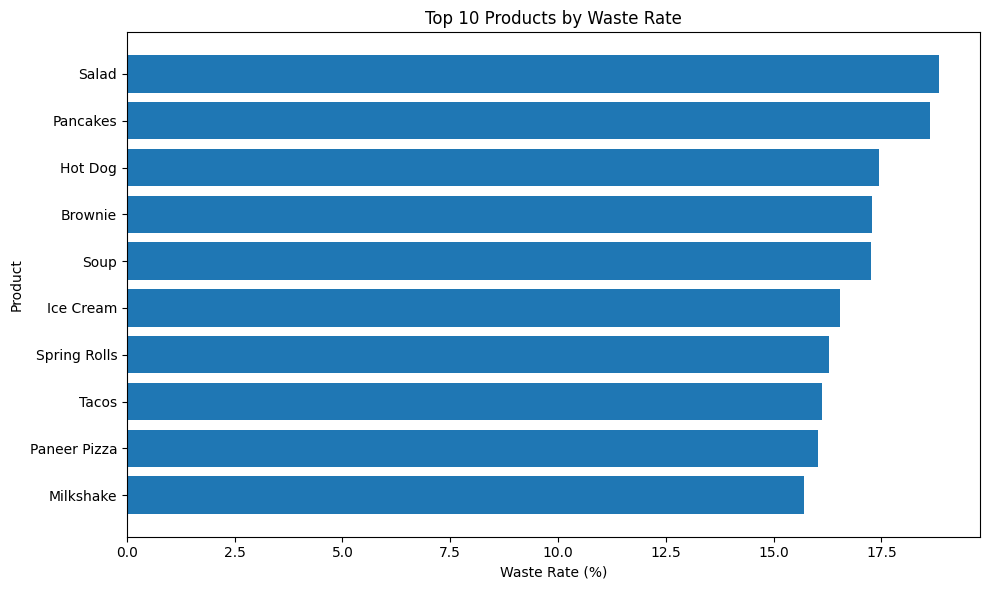

In [47]:
# ============================================
# TOP 10 PRODUCTS BY WASTE RATE
# ============================================

import matplotlib.pyplot as plt

top_10_products = (
    product_waste
    .sort_values("Waste_Rate", ascending=False)
    .head(10)
    .sort_values("Waste_Rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_products["Product_Name"],
    top_10_products["Waste_Rate"]
)

plt.xlabel("Waste Rate (%)")
plt.ylabel("Product")
plt.title("Top 10 Products by Waste Rate")

plt.tight_layout()
plt.show()

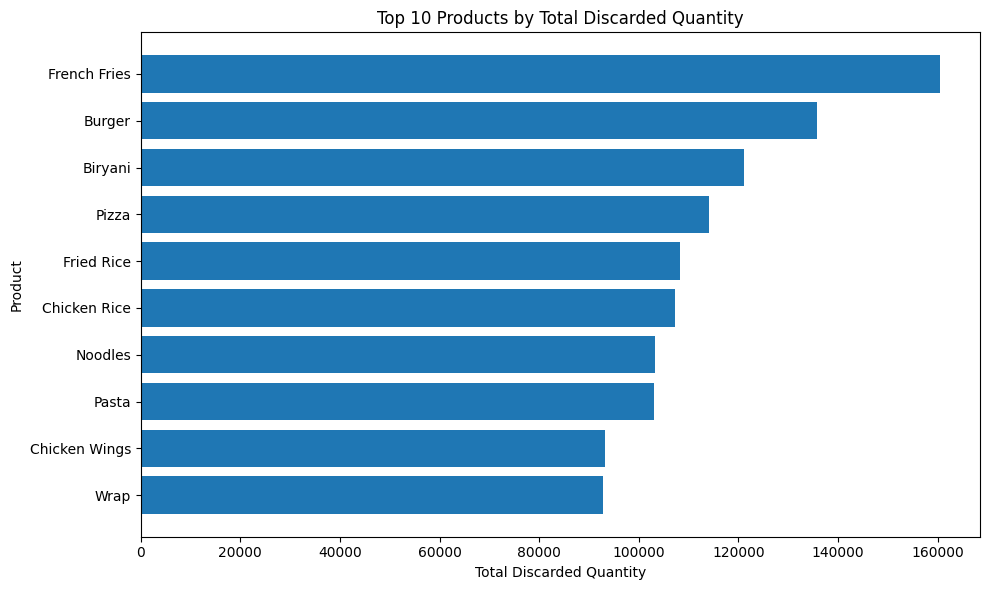

In [48]:
# ============================================
# TOP 10 PRODUCTS BY TOTAL DISCARDED QUANTITY
# ============================================

top_10_discarded = (
    product_waste
    .sort_values("Total_Discarded", ascending=False)
    .head(10)
    .sort_values("Total_Discarded")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_discarded["Product_Name"],
    top_10_discarded["Total_Discarded"]
)

plt.xlabel("Total Discarded Quantity")
plt.ylabel("Product")
plt.title("Top 10 Products by Total Discarded Quantity")

plt.tight_layout()
plt.show()

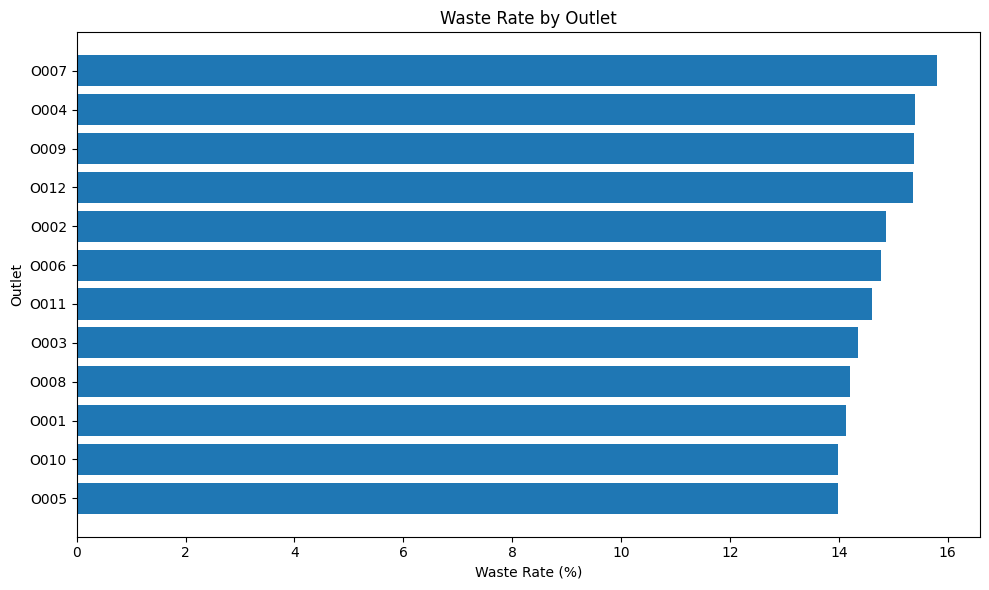

In [49]:
# ============================================
# WASTE RATE BY OUTLET
# ============================================

outlet_plot = (
    outlet_waste
    .sort_values("Waste_Rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    outlet_plot["Outlet_ID"],
    outlet_plot["Waste_Rate"]
)

plt.xlabel("Waste Rate (%)")
plt.ylabel("Outlet")
plt.title("Waste Rate by Outlet")

plt.tight_layout()
plt.show()

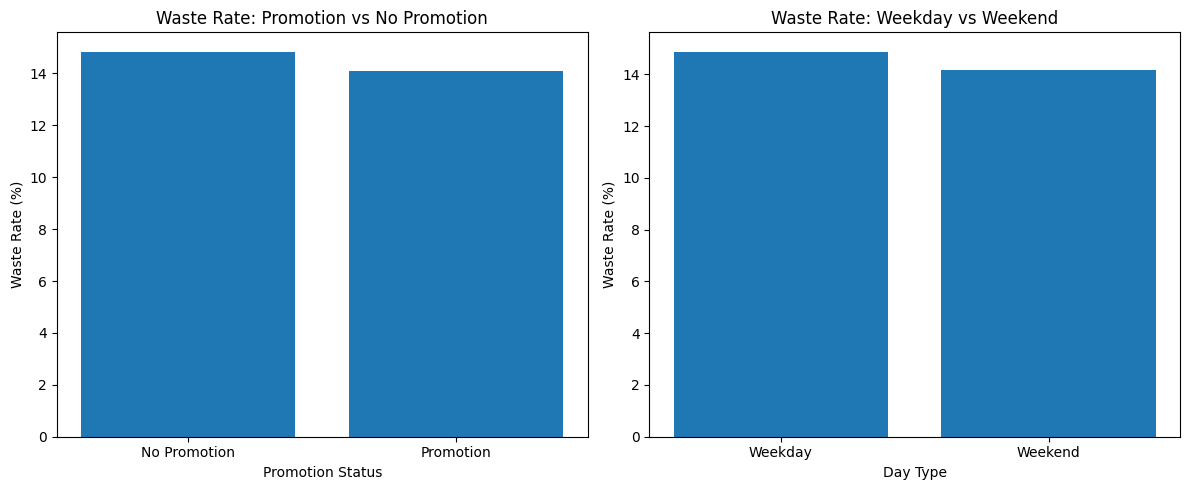

In [50]:
# ============================================
# PROMOTION AND WEEKEND WASTE COMPARISON
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Promotion
axes[0].bar(
    promotion_waste["Promotion_Status"],
    promotion_waste["Waste_Rate"]
)

axes[0].set_title("Waste Rate: Promotion vs No Promotion")
axes[0].set_ylabel("Waste Rate (%)")
axes[0].set_xlabel("Promotion Status")

# Weekday vs Weekend
axes[1].bar(
    weekend_waste["Day_Type"],
    weekend_waste["Waste_Rate"]
)

axes[1].set_title("Waste Rate: Weekday vs Weekend")
axes[1].set_ylabel("Waste Rate (%)")
axes[1].set_xlabel("Day Type")

plt.tight_layout()
plt.show()

In [51]:
# ============================================
# PREPARE DATA FOR RANDOM FOREST
# ============================================

ml_df = df.copy()

# Target variable
target = "Quantity_Discarded"

# Features available for the preparation/waste decision
features = [
    "Outlet_ID",
    "Product_ID",
    "Day_Number",
    "Month",
    "Weekend",
    "Weather",
    "Holiday",
    "Promotion",
    "Special_Event",
    "Base_Demand",
    "Outlet_Factor",
    "Day_Factor",
    "Promotion_Factor",
    "Weather_Factor",
    "Holiday_Factor",
    "Event_Factor",
    "Expected_Demand",
    "Quantity_Prepared"
]

X = ml_df[features].copy()
y = ml_df[target].copy()

print("Feature matrix shape :", X.shape)
print("Target shape         :", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Feature matrix shape : (263160, 18)
Target shape         : (263160,)

Features:
['Outlet_ID', 'Product_ID', 'Day_Number', 'Month', 'Weekend', 'Weather', 'Holiday', 'Promotion', 'Special_Event', 'Base_Demand', 'Outlet_Factor', 'Day_Factor', 'Promotion_Factor', 'Weather_Factor', 'Holiday_Factor', 'Event_Factor', 'Expected_Demand', 'Quantity_Prepared']

Target:
Quantity_Discarded


In [52]:
# ============================================
# ENCODE CATEGORICAL FEATURES
# ============================================

from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Outlet_ID",
    "Product_ID",
    "Weather"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_encoded = encoder.fit_transform(
    X[categorical_features]
)

encoded_columns = encoder.get_feature_names_out(
    categorical_features
)

X_categorical = pd.DataFrame(
    X_encoded,
    columns=encoded_columns,
    index=X.index
)

X_numeric = X.drop(
    columns=categorical_features
)

X_final = pd.concat(
    [X_numeric, X_categorical],
    axis=1
)

print("Original feature count :", X.shape[1])
print("Encoded feature count  :", X_final.shape[1])
print("Final feature matrix   :", X_final.shape)

Original feature count : 18
Encoded feature count  : 61
Final feature matrix   : (263160, 61)


In [53]:
# ============================================
# TIME-BASED TRAIN / TEST SPLIT
# ============================================

# Get unique dates in chronological order
unique_dates = sorted(df["Date"].unique())

# Use the first 80% of dates for training
split_index = int(len(unique_dates) * 0.80)
split_date = unique_dates[split_index]

train_mask = df["Date"] < split_date
test_mask = df["Date"] >= split_date

X_train = X_final.loc[train_mask]
X_test = X_final.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Split date:", split_date)

print("\nTraining:")
print("Rows:", X_train.shape[0])
print("Date range:", df.loc[train_mask, "Date"].min(),
      "to", df.loc[train_mask, "Date"].max())

print("\nTesting:")
print("Rows:", X_test.shape[0])
print("Date range:", df.loc[test_mask, "Date"].min(),
      "to", df.loc[test_mask, "Date"].max())

Split date: 2025-08-07 00:00:00

Training:
Rows: 210240
Date range: 2024-01-01 00:00:00 to 2025-08-06 00:00:00

Testing:
Rows: 52920
Date range: 2025-08-07 00:00:00 to 2025-12-31 00:00:00


In [54]:
# ============================================
# RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")
print("Number of trees:", rf_model.n_estimators)

Random Forest training completed.
Number of trees: 100


In [55]:
# ============================================
# RANDOM FOREST EVALUATION
# ============================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Performance")
print("-------------------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 4))

Random Forest Performance
-------------------------
MAE  : 5.53
RMSE : 6.91
R²   : 0.357


In [56]:
# ============================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    "Feature": X_final.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
14,Quantity_Prepared,0.586105
13,Expected_Demand,0.223988
1,Month,0.046164
0,Day_Number,0.023417
7,Outlet_Factor,0.016275
6,Base_Demand,0.012313
60,Weather_Sunny,0.008406
57,Weather_Cloudy,0.007114
58,Weather_Rainy,0.005533
8,Day_Factor,0.002956


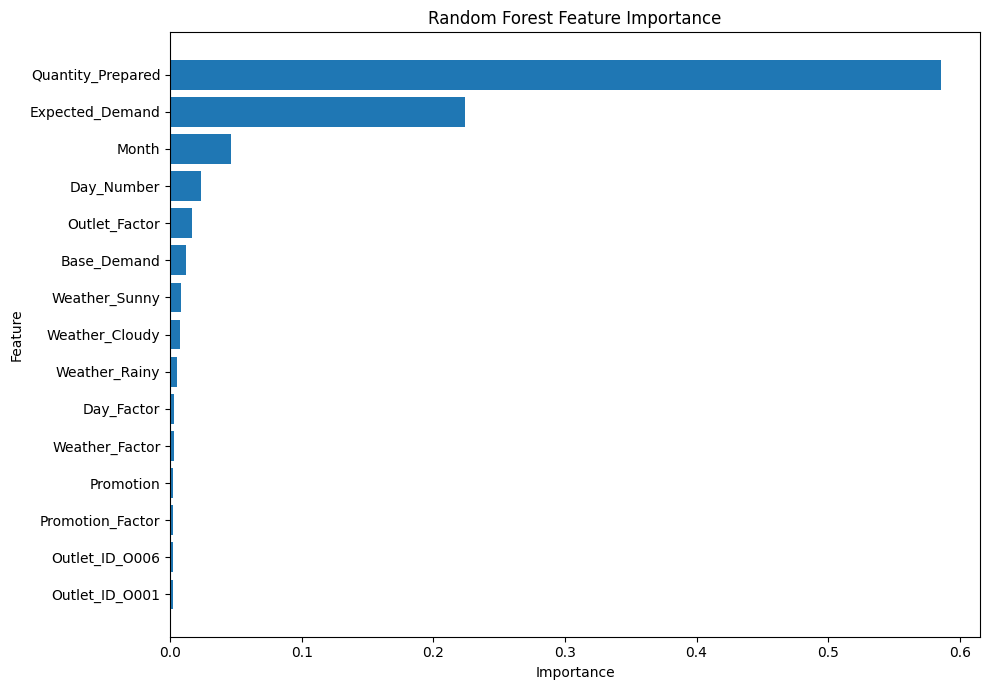

In [57]:
# ============================================
# RANDOM FOREST FEATURE IMPORTANCE PLOT
# ============================================

top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [58]:
# ============================================
# BASELINE: WASTE VS LOST DEMAND
# ============================================

baseline_metrics = {
    "Total Prepared": df["Quantity_Prepared"].sum(),
    "Total Sold": df["Quantity_Sold"].sum(),
    "Total Discarded": df["Quantity_Discarded"].sum(),
    "Total Lost Demand": df["Lost_Demand"].sum()
}

print("Baseline Preparation Metrics")
print("----------------------------")

for metric, value in baseline_metrics.items():
    print(f"{metric:20s}: {value:,}")

print("\nWaste Rate:",
      round(
          df["Quantity_Discarded"].sum()
          / df["Quantity_Prepared"].sum() * 100,
          2
      ),
      "%")

print("Lost Demand Rate:",
      round(
          df["Lost_Demand"].sum()
          / df["True_Demand"].sum() * 100,
          2
      ),
      "%")

Baseline Preparation Metrics
----------------------------
Total Prepared      : 17,713,315
Total Sold          : 15,118,503
Total Discarded     : 2,594,812
Total Lost Demand   : 280,564

Waste Rate: 14.65 %
Lost Demand Rate: 1.82 %


In [60]:
# ============================================
# CORRECT PREPARATION STRATEGY LABELS
# ============================================

preparation_levels = [
    (1.00, "100%"),
    (1.05, "105%"),
    (1.10, "110%"),
    (1.15, "115%")
]

strategy_results = []

for level, label in preparation_levels:

    simulated_prepared = (
        df["Expected_Demand"] * level
    ).round().astype(int)

    simulated_sold = (
        df["True_Demand"]
        .combine(simulated_prepared, min)
    )

    simulated_discarded = (
        simulated_prepared - simulated_sold
    ).clip(lower=0)

    simulated_lost_demand = (
        df["True_Demand"] - simulated_sold
    ).clip(lower=0)

    total_prepared = simulated_prepared.sum()
    total_discarded = simulated_discarded.sum()
    total_lost = simulated_lost_demand.sum()
    total_demand = df["True_Demand"].sum()

    strategy_results.append({
        "Preparation_Level": label,
        "Total_Prepared": total_prepared,
        "Total_Discarded": total_discarded,
        "Total_Lost_Demand": total_lost,
        "Waste_Rate": (
            total_discarded / total_prepared * 100
        ),
        "Lost_Demand_Rate": (
            total_lost / total_demand * 100
        )
    })

strategy_results = pd.DataFrame(strategy_results)

strategy_results

,Preparation_Level,Total_Prepared,Total_Discarded,Total_Lost_Demand,Waste_Rate,Lost_Demand_Rate
0,100%,15405448,841882,835501,5.464833,5.425660
1,105%,16173376,1291492,517183,7.985296,3.358535
2,110%,16948325,1860506,311248,10.977521,2.021213
3,115%,17710941,2500683,188809,14.119425,1.226107


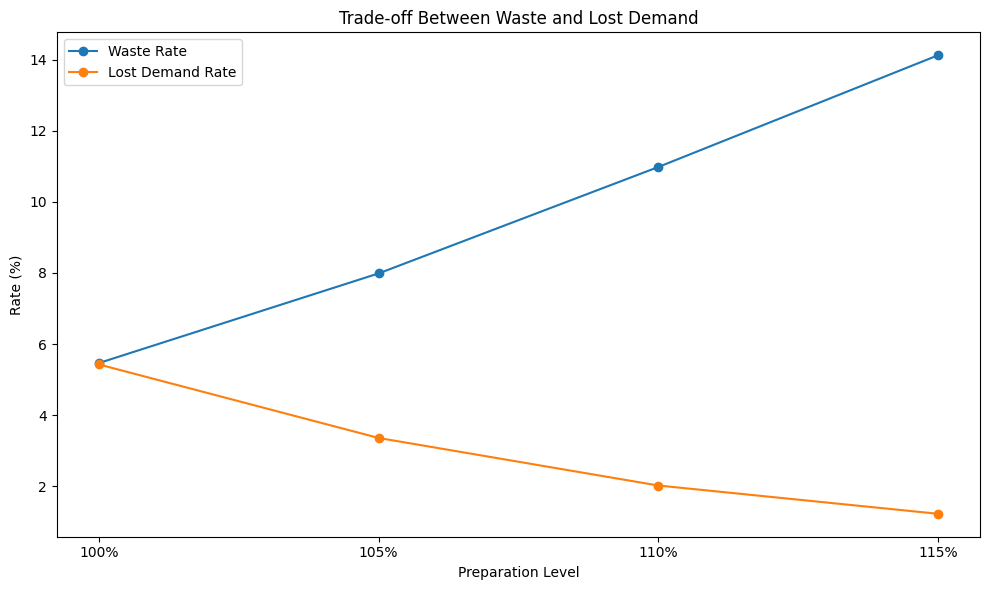

In [61]:
# ============================================
# PREPARATION LEVEL TRADE-OFF
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    strategy_results["Preparation_Level"],
    strategy_results["Waste_Rate"],
    marker="o",
    label="Waste Rate"
)

plt.plot(
    strategy_results["Preparation_Level"],
    strategy_results["Lost_Demand_Rate"],
    marker="o",
    label="Lost Demand Rate"
)

plt.xlabel("Preparation Level")
plt.ylabel("Rate (%)")
plt.title("Trade-off Between Waste and Lost Demand")
plt.legend()

plt.tight_layout()
plt.show()

In [62]:
# ============================================
# PRODUCT-LEVEL DEMAND-AWARE STRATEGY
# ============================================

strategy_level = 1.10

product_strategy = df.copy()

product_strategy["Recommended_Prepared"] = (
    product_strategy["Expected_Demand"] * strategy_level
).round().astype(int)

product_strategy["Recommended_Sold"] = (
    product_strategy["True_Demand"]
    .combine(product_strategy["Recommended_Prepared"], min)
)

product_strategy["Recommended_Discarded"] = (
    product_strategy["Recommended_Prepared"]
    - product_strategy["Recommended_Sold"]
).clip(lower=0)

product_strategy["Recommended_Lost_Demand"] = (
    product_strategy["True_Demand"]
    - product_strategy["Recommended_Sold"]
).clip(lower=0)

product_strategy_summary = (
    product_strategy
    .groupby(["Product_ID", "Product_Name"])
    .agg(
        Recommended_Prepared=("Recommended_Prepared", "sum"),
        Recommended_Discarded=("Recommended_Discarded", "sum"),
        Recommended_Lost_Demand=("Recommended_Lost_Demand", "sum")
    )
    .reset_index()
)

product_strategy_summary["Waste_Rate"] = (
    product_strategy_summary["Recommended_Discarded"]
    / product_strategy_summary["Recommended_Prepared"]
) * 100

product_strategy_summary.sort_values(
    "Recommended_Discarded",
    ascending=False
).head(10)

,Product_ID,Product_Name,Recommended_Prepared,Recommended_Discarded,Recommended_Lost_Demand,Waste_Rate
3,P004,French Fries,1155715,108607,2406,9.397386
0,P001,Burger,979663,93336,3911,9.527358
7,P008,Biryani,866130,83143,5221,9.599367
1,P002,Pizza,807532,79293,5515,9.819177
8,P009,Fried Rice,749780,75914,6758,10.124837
11,P012,Chicken Rice,748699,75372,6599,10.067063
4,P005,Pasta,712085,72038,7055,10.116489
9,P010,Noodles,711671,72012,6871,10.118721
6,P007,Wrap,635499,66523,8584,10.467837
2,P003,Chicken Wings,636097,66386,8325,10.436459


In [63]:
# ============================================
# CURRENT BASELINE VS 110% STRATEGY
# ============================================

baseline_waste = df["Quantity_Discarded"].sum()
baseline_lost = df["Lost_Demand"].sum()

strategy_waste = product_strategy["Recommended_Discarded"].sum()
strategy_lost = product_strategy["Recommended_Lost_Demand"].sum()

waste_reduction = baseline_waste - strategy_waste
lost_demand_increase = strategy_lost - baseline_lost

waste_reduction_pct = (
    waste_reduction / baseline_waste
) * 100

lost_demand_increase_pct = (
    lost_demand_increase / baseline_lost
) * 100

print("Current Baseline vs 110% Demand-Aware Strategy")
print("-----------------------------------------------")

print("Baseline Discarded       :", baseline_waste)
print("Strategy Discarded       :", strategy_waste)
print("Waste Reduction          :", waste_reduction)
print("Waste Reduction (%)      :", round(waste_reduction_pct, 2), "%")

print("\nBaseline Lost Demand     :", baseline_lost)
print("Strategy Lost Demand     :", strategy_lost)
print("Additional Lost Demand   :", lost_demand_increase)
print("Additional Lost Demand (%) :", round(lost_demand_increase_pct, 2), "%")

Current Baseline vs 110% Demand-Aware Strategy
-----------------------------------------------
Baseline Discarded       : 2594812
Strategy Discarded       : 1860506
Waste Reduction          : 734306
Waste Reduction (%)      : 28.3 %

Baseline Lost Demand     : 280564
Strategy Lost Demand     : 311248
Additional Lost Demand   : 30684
Additional Lost Demand (%) : 10.94 %


In [64]:
# ============================================
# FINAL STRATEGY SUMMARY
# ============================================

final_summary = pd.DataFrame({
    "Metric": [
        "Waste Rate",
        "Lost Demand Rate",
        "Total Discarded",
        "Total Lost Demand"
    ],
    "Current Baseline": [
        round(
            df["Quantity_Discarded"].sum()
            / df["Quantity_Prepared"].sum() * 100, 2
        ),
        round(
            df["Lost_Demand"].sum()
            / df["True_Demand"].sum() * 100, 2
        ),
        df["Quantity_Discarded"].sum(),
        df["Lost_Demand"].sum()
    ],
    "110% Demand-Aware Strategy": [
        round(
            strategy_waste
            / product_strategy["Recommended_Prepared"].sum() * 100, 2
        ),
        round(
            strategy_lost
            / df["True_Demand"].sum() * 100, 2
        ),
        strategy_waste,
        strategy_lost
    ]
})

final_summary

,Metric,Current Baseline,110% Demand-Aware Strategy
0,Waste Rate,14.65,10.98
1,Lost Demand Rate,1.82,2.02
2,Total Discarded,2594812.00,1860506.00
3,Total Lost Demand,280564.00,311248.00


# Final Findings and Recommendations

## Key Findings

- The overall simulated food waste rate was **14.65%**, with **2,594,812 units** discarded.
- **Salad** had the highest waste rate at approximately **18.84%**.
- **French Fries** generated the highest total discarded quantity at approximately **160,477 units**.
- Outlet-level waste rates varied across outlets, with **O007** showing the highest simulated waste rate at approximately **15.80%**.
- Promotion periods showed a simulated waste rate of **14.10%**, compared with **14.84%** without promotions.
- Weekends showed a simulated waste rate of **14.18%**, compared with **14.88%** on weekdays.
- Stormy weather had the highest simulated waste rate among the weather categories at approximately **15.30%**.
- The Random Forest model achieved:
  - **MAE:** 5.53
  - **RMSE:** 6.91
  - **R²:** 0.357
- Random Forest feature importance showed that **Quantity_Prepared** and **Expected_Demand** were the dominant predictive features.

## Demand-Aware Preparation Strategy

The preparation-level simulation demonstrated a clear trade-off between food waste and unmet demand.

The **110% of Expected_Demand** scenario produced:

- **10.98% waste rate**
- **2.02% lost-demand rate**
- **1,860,506 units discarded**
- **311,248 units of lost demand**

Compared with the current simulated baseline, this represents a **28.3% reduction in discarded quantity**, accompanied by a **10.94% increase in lost demand**.

Therefore, the analysis supports using **demand-aware preparation** rather than applying a fixed preparation buffer without considering expected demand.

## Practical Recommendations

1. Use expected demand to guide daily preparation quantities.
2. Monitor high-volume products such as French Fries, Burger, Biryani, and Pizza closely because they contribute substantially to total discarded quantity.
3. Monitor products with high waste rates separately, since high percentage waste and high absolute waste identify different operational priorities.
4. Incorporate outlet-level patterns when setting preparation quantities.
5. Consider promotion, weekday/weekend, weather, holidays, and special events when estimating expected demand.
6. Treat preparation levels as an adjustable policy rather than a fixed percentage.
7. Monitor both **waste rate** and **lost demand rate** so that reducing waste does not create excessive stockouts or unmet demand.

## Limitations

- The dataset is **synthetic** because no real restaurant dataset was provided.
- The relationships between demand, promotions, weather, holidays, and events were simulated during dataset generation.
- Therefore, the observed patterns should not be interpreted as causal evidence about real restaurant operations.
- The Random Forest model demonstrates predictive relationships within this simulated dataset but requires validation on real operational data before deployment.
- The preparation strategy is a scenario simulation and should be calibrated using actual demand, waste, stockout, and operational cost data.

In [65]:
# ============================================
# FINAL DATA & MODEL VALIDATION
# ============================================

print("FINAL VALIDATION")
print("================")

print("\nDataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nNegative discarded quantities:",
      (df["Quantity_Discarded"] < 0).sum())

print("Negative lost demand:",
      (df["Lost_Demand"] < 0).sum())

print("\nSold <= Prepared:",
      (df["Quantity_Sold"] <= df["Quantity_Prepared"]).all())

print("Prepared = Sold + Discarded:",
      (
          df["Quantity_Prepared"]
          == df["Quantity_Sold"] + df["Quantity_Discarded"]
      ).all())

print("True Demand = Sold + Lost Demand:",
      (
          df["True_Demand"]
          == df["Quantity_Sold"] + df["Lost_Demand"]
      ).all())

print("\nModel test predictions generated:",
      len(y_pred))

print("Final validation completed.")

FINAL VALIDATION

Dataset shape: (263160, 27)

Missing values:
0

Negative discarded quantities: 0
Negative lost demand: 0

Sold <= Prepared: True
Prepared = Sold + Discarded: True
True Demand = Sold + Lost Demand: True

Model test predictions generated: 52920
Final validation completed.
